<a href="https://colab.research.google.com/github/Nilufar-Komil/Applications-of-the-Generalized-Stiefel-Manifold-in-NN/blob/main/WRN_28_10/wrn_28_10_%2B_stiefel%2Bregularization_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch.nn as nn
import random
import torch # Main PyTorch Library
import torchvision # Pytorch library for image analysis
from torchvision import transforms  # Transform function used to modify and preprocess all the images
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
from torch.utils.data import random_split #Used to split data sets
device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [2]:
import torchvision.transforms as transforms

# Normalize all images: shift pixel values within -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=True,                     # use training data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=False,                    # use test data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

# print size of each data sets
print("Train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 170M/170M [03:44<00:00, 759kB/s]


Train size: 50000
Test size: 10000


In [4]:
!pip install nested-dict

  Preparing metadata (setup.py) ... done
  Created wheel for nested-dict: filename=nested_dict-1.61-py3-none-any.whl size=6428 sha256=80a385fd12cf3bf99a31aa6cd8a58fbb93236e4d51ed861c9d90c5d7e48ce5b9
  Stored in directory: /root/.cache/pip/wheels/80/29/c9/f0cda370d66969f99b58885cc5e62f2995a2f6d7ea7386d7fb
Successfully built nested-dict


In [5]:
# split full training data set to training and validation parts
train_size = int(0.8 * len(full_train_dataset))   # 80% for training
val_size = len(full_train_dataset) - train_size   # 20% for validation

train_dataset, val_dataset = random_split(
    full_train_dataset,             # dataset to split
    [train_size, val_size],         # sizes of split parts
    generator=torch.Generator().manual_seed(42)   # makes the train/validation split stay the same every time
)

# printing each data sets sizes
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train size: 40000
Val size: 10000
Test size: 10000


In [6]:
batch_size = 128


torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = False

In [7]:
#data loader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffled train batches
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)      # validation batches
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)    # test batches


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ProductGStiefelConv2d(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size,
        diffeo,
        stride: int = 1,
        padding: int = 0,
        bias: bool = False,
    ):
        super().__init__()

        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size

        kh, kw = self.kernel_size

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.diffeo = diffeo

        self.n = in_channels * kh * kw
        self.p = out_channels
        self.rank = diffeo.rank

        if self.p > self.n:
            raise ValueError(
                f"Infeasible layer: out_channels={self.p} > n={self.n}"
            )

        if not (self.p <= self.rank <= self.n):
            raise ValueError(
                f"Expected p <= rank <= n, got p={self.p}, rank={self.rank}, n={self.n}"
            )

        # Product coordinates:
        # diffeo uses X_std shape (rank, p), Z_std shape (n-rank, p).
        # We store transposed versions:
        # self.X shape = (p, rank)
        # self.Z shape = (p, n-rank)
        X_std, Z_std = diffeo.random_product_point(self.p)

        self.X = nn.Parameter(X_std.t().contiguous())
        self.Z = nn.Parameter(Z_std.t().contiguous())

        # Ambient gradient accumulator
        self.accumulate_ambient_grad = False
        self.ambient_grad_sum = None
        self.ambient_grad_count = 0

        if bias:
            self.bias = nn.Parameter(
                torch.zeros(out_channels, device=self.X.device, dtype=self.X.dtype)
            )
        else:
            self.register_parameter("bias", None)

    # --------------------------------------------------------
    # Return current ambient matrix W_flat with shape (n, p)
    # --------------------------------------------------------
    def reconstruct_matrix(self) -> torch.Tensor:
        X_std = self.X.t()
        Z_std = self.Z.t()

        W_flat = self.diffeo.phi_inverse(X_std, Z_std)

        if not isinstance(W_flat, torch.Tensor):
            raise TypeError("phi_inverse must return a torch.Tensor")

        return W_flat

    # --------------------------------------------------------
    # Return convolution weight with shape:
    #   (out_channels, in_channels, kh, kw)
    # --------------------------------------------------------
    def reconstruct_weight(self) -> torch.Tensor:
        W_flat = self.reconstruct_matrix()

        kh, kw = self.kernel_size

        W = W_flat.t().contiguous().view(
            self.out_channels,
            self.in_channels,
            kh,
            kw,
        )

        return W

    # --------------------------------------------------------
    # Constraint error:
    #   ||W^T S W - I||
    # --------------------------------------------------------
    @torch.no_grad()
    def constraint_error(self) -> torch.Tensor:
        W_flat = self.reconstruct_matrix()
        return self.diffeo.constraint_error(W_flat)

    # --------------------------------------------------------
    # Reset ambient gradient accumulator
    # --------------------------------------------------------
    def reset_ambient_gradient_accumulator(self):
        self.accumulate_ambient_grad = True
        self.ambient_grad_sum = None
        self.ambient_grad_count = 0

    # --------------------------------------------------------
    # Stop accumulating ambient gradients
    # --------------------------------------------------------
    def stop_ambient_gradient_accumulator(self):
        self.accumulate_ambient_grad = False

    # --------------------------------------------------------
    # Return average ambient gradient G wrt W_flat
    # shape: (n, p)
    # --------------------------------------------------------
    def get_average_ambient_gradient(self):
        if self.ambient_grad_sum is None or self.ambient_grad_count == 0:
            return None

        return self.ambient_grad_sum / self.ambient_grad_count

    # --------------------------------------------------------
    # Refresh product coordinates after the metric S changes.
    #
    # Important:
    #   This replaces nn.Parameters, so the optimizer must be rebuilt.
    # --------------------------------------------------------
    @torch.no_grad()
    def refresh_product_coordinates_from_current_weight(self) -> None:
        W_flat = self.reconstruct_matrix().detach()

        X_std, Z_std = self.diffeo.phi(W_flat)

        self.X = nn.Parameter(X_std.t().contiguous())
        self.Z = nn.Parameter(Z_std.t().contiguous())

        self.rank = self.diffeo.rank

    # --------------------------------------------------------
    # Apply adaptive rank reduction using average ambient gradient.
    #
    # G_flat must have shape (n, p).
    # --------------------------------------------------------
    @torch.no_grad()
    def reduce_rank_using_gradient(
        self,
        G_flat: torch.Tensor,
        r_target: int | None = None,
        svd_tol: float = 1e-8,
        verbose: bool = False,
    ) -> bool:
        # Reconstruct W before changing the metric
        W_flat = self.reconstruct_matrix().detach()

        reduced = self.diffeo.reduce_rank_using_gradient(
            W=W_flat,
            G=G_flat,
            r_target=r_target,
            svd_tol=svd_tol,
            verbose=verbose,
        )

        if reduced:
            # Convert the same W into product coordinates for the new metric
            X_std, Z_std = self.diffeo.phi(W_flat)

            self.X = nn.Parameter(X_std.t().contiguous())
            self.Z = nn.Parameter(Z_std.t().contiguous())

            self.rank = self.diffeo.rank

        return reduced

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        W = self.reconstruct_weight()

        # Accumulate gradient wrt ambient convolution weight W.
        # This gives G = grad_W L in shape (n, p).
        if self.training and getattr(self, "accumulate_ambient_grad", False):

            def save_ambient_grad(grad):
                # grad shape:
                #   (out_channels, in_channels, kh, kw)
                #
                # convert to W_flat gradient shape:
                #   (n, p)
                G_flat = grad.detach().view(self.out_channels, -1).t().contiguous()

                if self.ambient_grad_sum is None:
                    self.ambient_grad_sum = torch.zeros_like(G_flat)

                self.ambient_grad_sum += G_flat
                self.ambient_grad_count += 1

            W.register_hook(save_ambient_grad)

        return F.conv2d(
            x,
            W,
            bias=self.bias,
            stride=self.stride,
            padding=self.padding,
        )

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class WRNBasicBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        dropout=0.3,
        conv0_layer=None,
        conv1_layer=None,
    ):
        super().__init__()
        self.equal_in_out = (in_channels == out_channels)
        self.dropout = dropout

        self.bn0 = nn.BatchNorm2d(in_channels)

        self.conv0 = conv0_layer if conv0_layer is not None else nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv1 = conv1_layer if conv1_layer is not None else nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )

        self.convdim = None
        if not self.equal_in_out:
            self.convdim = nn.Conv2d(
                in_channels, out_channels,
                kernel_size=1, stride=stride, padding=0, bias=False
            )

        self.reset_parameters()

    def reset_parameters(self):
        if isinstance(self.conv0, nn.Conv2d):
            nn.init.orthogonal_(self.conv0.weight)
        if isinstance(self.conv1, nn.Conv2d):
            nn.init.orthogonal_(self.conv1.weight)
        if self.convdim is not None:
            nn.init.orthogonal_(self.convdim.weight)

        nn.init.ones_(self.bn0.weight)
        nn.init.zeros_(self.bn0.bias)
        nn.init.ones_(self.bn1.weight)
        nn.init.zeros_(self.bn1.bias)

    def forward(self, x):
        o1 = F.relu(self.bn0(x), inplace=True)

        y = self.conv0(o1)
        o2 = F.relu(self.bn1(y), inplace=True)
        o2 = F.dropout(o2, p=self.dropout, training=self.training)
        z = self.conv1(o2)

        shortcut = self.convdim(o1) if self.convdim is not None else x
        return z + shortcut


In [10]:
class WRNGroup(nn.Module):
    def __init__(
        self,
        num_blocks,
        in_channels,
        out_channels,
        first_stride,
        dropout=0.3,
        block_builder=None,
        group_index=None,
    ):
        super().__init__()
        blocks = []

        for i in range(num_blocks):
            stride = first_stride if i == 0 else 1
            block_in = in_channels if i == 0 else out_channels

            if block_builder is None:
                block = WRNBasicBlock(
                    in_channels=block_in,
                    out_channels=out_channels,
                    stride=stride,
                    dropout=dropout,
                )
            else:
                block = block_builder(
                    group_index=group_index,
                    block_index=i,
                    in_channels=block_in,
                    out_channels=out_channels,
                    stride=stride,
                    dropout=dropout,
                )

            blocks.append(block)

        self.blocks = nn.Sequential(*blocks)

    def forward(self, x):
        return self.blocks(x)

In [11]:
class WideResNet(nn.Module):
    def __init__(
        self,
        depth=28,
        width=10,
        num_classes=10,
        dropout=0.3,
        stem_layer=None,
        block_builder=None,
    ):
        super().__init__()
        assert (depth - 4) % 6 == 0, "depth should be 6n+4"

        n = (depth - 4) // 6
        widths = [16 * width, 32 * width, 64 * width]

        self.conv0 = stem_layer if stem_layer is not None else nn.Conv2d(
            3, 16, kernel_size=3, stride=1, padding=1, bias=False
        )

        self.group0 = WRNGroup(
            num_blocks=n,
            in_channels=16,
            out_channels=widths[0],
            first_stride=1,
            dropout=dropout,
            block_builder=block_builder,
            group_index=0,
        )
        self.group1 = WRNGroup(
            num_blocks=n,
            in_channels=widths[0],
            out_channels=widths[1],
            first_stride=2,
            dropout=dropout,
            block_builder=block_builder,
            group_index=1,
        )
        self.group2 = WRNGroup(
            num_blocks=n,
            in_channels=widths[1],
            out_channels=widths[2],
            first_stride=2,
            dropout=dropout,
            block_builder=block_builder,
            group_index=2,
        )

        self.bn = nn.BatchNorm2d(widths[2])
        self.fc = nn.Linear(widths[2], num_classes)

        self.reset_parameters()

    def reset_parameters(self):
        if isinstance(self.conv0, nn.Conv2d):
            nn.init.orthogonal_(self.conv0.weight)

        nn.init.ones_(self.bn.weight)
        nn.init.zeros_(self.bn.bias)

        nn.init.normal_(self.fc.weight, mean=0.0, std=2 / (self.fc.in_features ** 0.5))
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        x = self.conv0(x)
        x = self.group0(x)
        x = self.group1(x)
        x = self.group2(x)
        x = F.relu(self.bn(x), inplace=True)
        x = F.avg_pool2d(x, 8, 1, 0)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [12]:
from __future__ import annotations
import torch


def sym(A: torch.Tensor) -> torch.Tensor:
    return 0.5 * (A + A.T)


class GeneralizedStiefelDiffeomorphismTorch:
    """
    Diffeomorphism between the generalized Stiefel manifold

        St_S(n, p) = { W in R^{n x p} : W^T S W = I_p }

    and the product manifold

        St(r, p) x R^{(n-r) x p},

    where r = rank(S).

    This version also supports adaptive rank reduction:

        S -> S'

    using the update

        S' = U' P Z^{-2} P^T U'^T,

    where

        A = U'^T W = P Z V^T.

    Here U' is obtained by removing the least gradient-sensitive
    eigendirection of S.
    """

    def __init__(self, S: torch.Tensor, tol: float = 1e-10):
        self.tol = tol
        self.set_metric(S)

    # --------------------------------------------------------
    # Set or reset the metric S and recompute its eigendecomposition
    # --------------------------------------------------------
    def set_metric(self, S: torch.Tensor) -> None:
        self.S = sym(S)

        # Keep B as an alias for compatibility with older code
        self.B = self.S

        self.device = S.device
        self.dtype = S.dtype

        if S.ndim != 2 or S.shape[0] != S.shape[1]:
            raise ValueError("S must be a square matrix.")

        self.n = S.shape[0]

        evals, Q = torch.linalg.eigh(self.S)

        # Sort eigenvalues from largest to smallest
        idx = torch.argsort(evals, descending=True)
        evals = evals[idx]
        Q = Q[:, idx]

        if torch.any(evals < -self.tol):
            raise ValueError("S must be positive semidefinite.")

        rank = int((evals > self.tol).sum().item())

        self.rank = rank
        self.Q = Q
        self.evals = evals

        self.Q1 = Q[:, :rank]
        self.Q2 = Q[:, rank:]

        if rank > 0:
            lam = evals[:rank]

            self.Lambda = torch.diag(lam)
            self.Lambda_half = torch.diag(torch.sqrt(lam))
            self.Lambda_half_inv = torch.diag(1.0 / torch.sqrt(lam))
        else:
            self.Lambda = torch.empty((0, 0), device=self.device, dtype=self.dtype)
            self.Lambda_half = torch.empty((0, 0), device=self.device, dtype=self.dtype)
            self.Lambda_half_inv = torch.empty((0, 0), device=self.device, dtype=self.dtype)

    # --------------------------------------------------------
    # Check W^T S W = I
    # --------------------------------------------------------
    def in_generalized_stiefel(self, W: torch.Tensor) -> bool:
        if W.ndim != 2 or W.shape[0] != self.n:
            return False

        p = W.shape[1]
        gram = W.T @ self.S @ W
        I = torch.eye(p, device=W.device, dtype=W.dtype)

        return torch.norm(gram - I) <= 1e2 * self.tol

    # --------------------------------------------------------
    # Constraint error ||W^T S W - I||
    # Useful for logging
    # --------------------------------------------------------
    def constraint_error(self, W: torch.Tensor) -> torch.Tensor:
        if W.ndim != 2 or W.shape[0] != self.n:
            raise ValueError(f"W must have shape ({self.n}, p).")

        p = W.shape[1]
        I = torch.eye(p, device=W.device, dtype=W.dtype)

        return torch.norm(W.T @ self.S @ W - I)

    # --------------------------------------------------------
    # Map W -> (X, Z)
    # --------------------------------------------------------
    def phi(self, W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        if W.ndim != 2 or W.shape[0] != self.n:
            raise ValueError(f"W must have shape ({self.n}, p).")

        QtW = self.Q.T @ W

        W1 = QtW[:self.rank, :]
        W2 = QtW[self.rank:, :]

        if self.rank > 0:
            X = self.Lambda_half @ W1
        else:
            X = torch.empty((0, W.shape[1]), device=W.device, dtype=W.dtype)

        Z = W2

        return X, Z

    # --------------------------------------------------------
    # Map (X, Z) -> W
    # --------------------------------------------------------
    def phi_inverse(self, X: torch.Tensor, Z: torch.Tensor) -> torch.Tensor:
        if X.ndim != 2:
            raise ValueError("X must be a matrix of shape (rank, p).")

        if Z.ndim != 2:
            raise ValueError("Z must be a matrix of shape (n-rank, p).")

        if X.shape[1] != Z.shape[1]:
            raise ValueError("X and Z must have the same number of columns.")

        if X.shape[0] != self.rank:
            raise ValueError(f"X must have shape ({self.rank}, p).")

        if Z.shape[0] != self.n - self.rank:
            raise ValueError(f"Z must have shape ({self.n - self.rank}, p).")

        if self.rank > 0:
            W1 = self.Lambda_half_inv @ X
        else:
            W1 = torch.empty((0, X.shape[1]), device=X.device, dtype=X.dtype)

        W = self.Q1 @ W1 + self.Q2 @ Z

        return W

    # --------------------------------------------------------
    # Random product point
    # --------------------------------------------------------
    def random_product_point(self, p: int) -> tuple[torch.Tensor, torch.Tensor]:
        if p > self.rank:
            raise ValueError(
                f"Cannot create St({self.rank}, {p}). "
                f"Need p <= rank(S), but got p={p}, rank(S)={self.rank}."
            )

        A = torch.randn(self.rank, p, device=self.device, dtype=self.dtype)
        Qx, Rx = torch.linalg.qr(A, mode="reduced")

        d = torch.diagonal(Rx, 0)
        s = torch.sign(d)
        s[s == 0] = 1
        Qx = Qx * s.unsqueeze(0)

        X = Qx
        Z = torch.zeros(self.n - self.rank, p, device=self.device, dtype=self.dtype)

        return X, Z

    # --------------------------------------------------------
    # Initialize product coordinates from feasible W
    # --------------------------------------------------------
    def init_from_W(self, W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        if not self.in_generalized_stiefel(W):
            raise ValueError("Input W does not satisfy W^T S W = I up to tolerance.")

        return self.phi(W)

    # --------------------------------------------------------
    # Adaptive rank-reduction update
    #
    # Input:
    #   W : current ambient matrix, shape (n, p)
    #   G : average gradient wrt W, shape (n, p)
    #
    # Output:
    #   reduced : bool
    #
    # If successful:
    #   self.S is replaced by S'
    #   self.rank decreases by 1
    # --------------------------------------------------------
    @torch.no_grad()
    def reduce_rank_using_gradient(
        self,
        W: torch.Tensor,
        G: torch.Tensor,
        r_target: int | None = None,
        svd_tol: float = 1e-8,
        verbose: bool = False,
    ) -> bool:
        if W.ndim != 2 or W.shape[0] != self.n:
            raise ValueError(f"W must have shape ({self.n}, p).")

        if G.shape != W.shape:
            raise ValueError("G must have the same shape as W.")

        p = W.shape[1]
        r = self.rank

        # Feasibility condition: rank(S) must stay at least p
        if r <= p:
            if verbose:
                print(f"No rank reduction: rank(S)={r} is already minimal for p={p}.")
            return False

        if r_target is not None and r <= r_target:
            if verbose:
                print(f"No rank reduction: rank(S)={r} <= r_target={r_target}.")
            return False

        if r_target is not None and r_target < p:
            raise ValueError(
                f"Invalid r_target={r_target}. Need r_target >= p={p}."
            )

        U = self.Q1  # active eigenspace, shape (n, r)

        # Sensitivity scores:
        # s_i = ||u_i^T G||_2
        projected_grad = U.T @ G          # shape (r, p)
        scores = torch.norm(projected_grad, dim=1)

        j = int(torch.argmin(scores).item())

        # Remove u_j from U
        keep_mask = torch.ones(r, dtype=torch.bool, device=W.device)
        keep_mask[j] = False
        U_new = U[:, keep_mask]           # shape (n, r-1)

        # Important corrected formula:
        # A = U'^T W
        A = U_new.T @ W                   # shape (r-1, p)

        # Need A to have full column rank
        P, singular_values, Vh = torch.linalg.svd(A, full_matrices=False)

        if singular_values.numel() < p:
            if verbose:
                print("No rank reduction: SVD returned too few singular values.")
            return False

        min_sv = singular_values.min().item()
        if min_sv <= svd_tol:
            if verbose:
                print(
                    f"No rank reduction: A = U'^T W is rank deficient. "
                    f"min singular value = {min_sv:.3e}"
                )
            return False

        Z_inv_sq = torch.diag(1.0 / (singular_values ** 2))

        # M = P Z^{-2} P^T
        M = P @ Z_inv_sq @ P.T

        # S' = U' M U'^T
        S_new = U_new @ M @ U_new.T
        S_new = sym(S_new)

        # Update internal metric/eigendecomposition
        old_rank = self.rank
        removed_score = scores[j].item()

        self.set_metric(S_new)

        if verbose:
            print(
                f"Reduced rank(S): {old_rank} -> {self.rank}. "
                f"Removed direction index {j}, score={removed_score:.4e}."
            )

        return True

    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------
    def print_summary(self) -> None:
        print(f"n = {self.n}")
        print(f"rank(S) = {self.rank}")
        print("positive eigenvalues =", self.evals[:self.rank])
        print("Q1 shape =", tuple(self.Q1.shape))
        print("Q2 shape =", tuple(self.Q2.shape))

In [13]:
#a helper that decides whether a layer should be constrained
def is_feasible_gstiefel_conv(in_channels, out_channels, kernel_size, rank):
    n = in_channels * kernel_size * kernel_size
    p = out_channels
    return (p <= n) and (p <= rank <= n)

In [14]:
import math
import torch

dtype = torch.float32


def make_initial_S_for_conv(n, device, dtype=torch.float32):
    """
    Initial adaptive metric:

        S_0 = I_n

    Therefore:

        rank(S_0) = n.

    Rank reduction will happen later during training.
    """
    return torch.eye(n, device=device, dtype=dtype)


def make_target_rank_for_conv(n, p):
    """
    Minimal feasible target rank.

    For X^T S X = I_p, we need rank(S) >= p.
    Therefore the smallest possible target rank is p.
    """
    return p


def diffeo_factory(
    in_channels,
    out_channels,
    kernel_size,
    group_index,
    block_index,
    conv_name,
):
    """
    Create one adaptive generalized Stiefel diffeomorphism for one conv layer.

    We reshape Conv2d weights as:

        W_conv shape = (out_channels, in_channels, k, k)

    into

        X shape = (n, p),

    where

        n = in_channels * k * k
        p = out_channels.

    We initialize:

        S_0 = I_n,

    and later reduce rank(S) during training.
    """

    if isinstance(kernel_size, tuple):
        kernel_h, kernel_w = kernel_size
    else:
        kernel_h = kernel_w = kernel_size

    n = in_channels * kernel_h * kernel_w
    p = out_channels

    if p > n:
        raise ValueError(
            f"Infeasible layer: p={p} > n={n} for {conv_name}, "
            f"group={group_index}, block={block_index}."
        )

    # Start with full-rank identity metric
    S0 = make_initial_S_for_conv(
        n=n,
        device=device,
        dtype=torch.float32,
    )

    # Final rank we want to reach later
    r_target = make_target_rank_for_conv(n=n, p=p)

    diffeo = GeneralizedStiefelDiffeomorphismTorch(S=S0)

    # Store useful layer metadata inside the diffeo object
    diffeo.n_conv = n
    diffeo.p_conv = p
    diffeo.r_target = r_target
    diffeo.layer_name = (
        "stem"
        if conv_name == "stem"
        else f"group{group_index}.block{block_index}.{conv_name}"
    )

    if diffeo.rank < p:
        raise ValueError(
            f"rank(S)={diffeo.rank} < p={p} for {diffeo.layer_name}."
        )

    print(
        f"{diffeo.layer_name}: "
        f"n={n}, p={p}, "
        f"initial_rank={diffeo.rank}, "
        f"target_rank={diffeo.r_target}"
    )

    return diffeo

In [15]:
import gc
import torch

# Delete old objects if they already exist
for obj_name in [
    "model",
    "stiefel_optimizer",
    "euclid_optimizer",
    "optimizer",
    "stem_layer",
    "block_builder",
    "constrained_layers",
]:
    if obj_name in globals():
        del globals()[obj_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("CUDA cache cleared.")

CUDA cache cleared.


In [16]:
def make_block_builder(diffeo_factory):
    """
    diffeo_factory(in_channels, out_channels, kernel_size, group_index, block_index, conv_name)
    should return a diffeo object with appropriate B/rank for that layer.
    """

    def build_block(group_index, block_index, in_channels, out_channels, stride, dropout):
        # conv0: first conv inside block
        # skip constraint for the known infeasible WRN layer: group0.block0.conv0 (16 -> 160, 3x3)
        use_gs_conv0 = not (group_index == 0 and block_index == 0)

        conv0_layer = None
        if use_gs_conv0:
            diffeo0 = diffeo_factory(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                group_index=group_index,
                block_index=block_index,
                conv_name="conv0",
            )
            if is_feasible_gstiefel_conv(in_channels, out_channels, 3, diffeo0.rank):
                conv0_layer = ProductGStiefelConv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=3,
                    diffeo=diffeo0,
                    stride=stride,
                    padding=1,
                    bias=False,
                )

        # conv1: always out_channels -> out_channels, usually feasible in WRN-28-10
        conv1_layer = None
        diffeo1 = diffeo_factory(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            group_index=group_index,
            block_index=block_index,
            conv_name="conv1",
        )
        if is_feasible_gstiefel_conv(out_channels, out_channels, 3, diffeo1.rank):
            conv1_layer = ProductGStiefelConv2d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel_size=3,
                diffeo=diffeo1,
                stride=1,
                padding=1,
                bias=False,
            )

        return WRNBasicBlock(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=stride,
            dropout=dropout,
            conv0_layer=conv0_layer,
            conv1_layer=conv1_layer,
        )

    return build_block

In [17]:
def make_stem_layer(diffeo_factory):
    diffeo = diffeo_factory(
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        group_index=-1,
        block_index=-1,
        conv_name="stem",
    )
    return ProductGStiefelConv2d(
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        diffeo=diffeo,
        stride=1,
        padding=1,
        bias=False,
    )

In [18]:
stem_layer = make_stem_layer(diffeo_factory)
block_builder = make_block_builder(diffeo_factory)

stem: n=27, p=16, initial_rank=27, target_rank=16


In [19]:
model = WideResNet(
    depth=28,
    width=10,
    num_classes=10,
    dropout=0.3,
    stem_layer=stem_layer,
    block_builder=block_builder,
).to(device)

group0.block0.conv1: n=1440, p=160, initial_rank=1440, target_rank=160
group0.block1.conv0: n=1440, p=160, initial_rank=1440, target_rank=160
group0.block1.conv1: n=1440, p=160, initial_rank=1440, target_rank=160
group0.block2.conv0: n=1440, p=160, initial_rank=1440, target_rank=160
group0.block2.conv1: n=1440, p=160, initial_rank=1440, target_rank=160
group0.block3.conv0: n=1440, p=160, initial_rank=1440, target_rank=160
group0.block3.conv1: n=1440, p=160, initial_rank=1440, target_rank=160
group1.block0.conv0: n=1440, p=320, initial_rank=1440, target_rank=320
group1.block0.conv1: n=2880, p=320, initial_rank=2880, target_rank=320
group1.block1.conv0: n=2880, p=320, initial_rank=2880, target_rank=320
group1.block1.conv1: n=2880, p=320, initial_rank=2880, target_rank=320
group1.block2.conv0: n=2880, p=320, initial_rank=2880, target_rank=320
group1.block2.conv1: n=2880, p=320, initial_rank=2880, target_rank=320
group1.block3.conv0: n=2880, p=320, initial_rank=2880, target_rank=320
group1

In [20]:
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss

In [23]:
#utils_modify
import math
import torch
import torch.nn as nn
import torch.cuda.comm as comm
from torch.nn.parallel._functions import Broadcast
from torch.nn.parallel import scatter, parallel_apply, gather
from functools import partial
from torch.autograd import Variable
from nested_dict import nested_dict
from collections import OrderedDict


def cast(params, dtype='float', device='cuda'):
    if isinstance(params, dict):
        return {k: cast(v, dtype=dtype, device=device) for k, v in params.items()}
    else:
        tensor = params.to(device) if device is not None else params
        return getattr(tensor, dtype)()


def conv_params(ni, no, k=1, g=1):
    assert ni % g == 0
    w = nn.init.orthogonal_(torch.empty(no, ni // g, k, k))
    return cast(w)


def linear_params(ni, no):
    return cast(dict(
        weight=torch.empty(no, ni).normal_(0, 2 / math.sqrt(ni)),
        bias=torch.zeros(no)
    ))


def bnparams(n):
    return cast(dict(
        weight=torch.ones(n),
        bias=torch.zeros(n)
    ))


def bnstats(n):
    return cast(dict(
        running_mean=torch.zeros(n),
        running_var=torch.ones(n)
    ))


def data_parallel(f, input, params, stats, mode, device_ids, output_device=None):
    if output_device is None:
        output_device = device_ids[0]

    if len(device_ids) == 1:
        return f(input, params, stats, mode)

    def replicate(param_dict, g):
        replicas = [{} for _ in device_ids]
        for k, v in param_dict.items():
            for i, u in enumerate(g(v)):
                replicas[i][k] = u
        return replicas

    params_replicas = replicate(params, lambda x: Broadcast(device_ids)(x))
    stats_replicas = replicate(stats, lambda x: comm.broadcast(x, device_ids))

    replicas = [
        partial(f, params=p, stats=s, mode=mode)
        for p, s in zip(params_replicas, stats_replicas)
    ]
    inputs = scatter([input], device_ids)
    outputs = parallel_apply(replicas, inputs)
    return gather(outputs, output_device)


def flatten_params(params):
    flat_params = OrderedDict()
    for keys, v in nested_dict(params).items_flat():
        if v is not None:
            flat_params['.'.join(keys)] = Variable(v, requires_grad=True)
    return flat_params


def flatten_stats(stats):
    flat_stats = OrderedDict()
    for keys, v in nested_dict(stats).items_flat():
        flat_stats['.'.join(keys)] = v
    return flat_stats


def matrix_norm_one(W):
    out = torch.abs(W)
    out = torch.sum(out, dim=0)
    out = torch.max(out)
    return out

In [24]:
#gutils_modify
import torch


def norm(v, dim=1):
    assert len(v.size()) == 2
    return v.norm(p=2, dim=dim, keepdim=True)


def unit(v, dim=1, eps=1e-8):
    vnorm = norm(v, dim)
    return v / vnorm.add(eps), vnorm


def xTy(x, y):
    assert len(x.size()) == 2 and len(y.size()) == 2, 'xTy'
    return torch.sum(x * y, dim=1, keepdim=True)


def clip_by_norm(v, clip_norm):
    v_norm = norm(v)
    scale = torch.ones_like(v_norm)
    mask = v_norm > clip_norm
    scale[mask] = clip_norm / v_norm[mask]
    return v * scale


def sym_matrix(y):  # y n-by-n
    assert y.size(0) == y.size(1)
    return (y + y.t()) / 2


def skew_matrix(y):  # y n-by-n
    assert y.size(0) == y.size(1)
    return (y - y.t()) / 2


def stiefel_proj_tan(y, g):  # y,g p-by-n, p <= n
    p, n = y.size()
    skew = skew_matrix(torch.matmul(y, g.t()))
    reflect = torch.matmul(y.t(), y)
    identity = torch.eye(n, device=y.device, dtype=y.dtype)
    reflect = identity - reflect
    tan_vec = torch.matmul(y.t(), skew) + torch.matmul(reflect, g.t())
    return tan_vec.t()


def stiefel_proj_norm(y, g):  # y,g p-by-n, p <= n
    sym = sym_matrix(torch.matmul(y, g.t()))
    norm_vec = torch.matmul(y.t(), sym)
    return norm_vec.t()


def polar_retraction(tan_vec):  # tan_vec, p-by-n, p <= n
    p, n = tan_vec.size()
    U, S, Vh = torch.linalg.svd(tan_vec, full_matrices=False)
    return torch.matmul(U, Vh)


def qr_retraction(tan_vec):  # tan_vec, p-by-n, p <= n
    q, r = torch.linalg.qr(tan_vec.t(), mode='reduced')  # n-by-p
    d = torch.diagonal(r, 0)
    ph = d.sign()
    ph[ph == 0] = 1
    q = q * ph.unsqueeze(0).expand_as(q)
    return q.t()


def Cayley_loop(X, W, tan_vec, t):
    # X: n-by-p
    # W: n-by-n skew-symmetric
    # tan_vec: n-by-p
    Y = X + t * tan_vec
    for _ in range(5):
        Y = X + t * torch.matmul(W, 0.5 * (X + Y))
    return Y.t()


def check_identity(X):  # X: n-by-p
    n, p = X.size()
    res = torch.eye(p, device=X.device, dtype=X.dtype) - torch.mm(X.t(), X)
    print('n={0}, p={1}, res norm={2}'.format(n, p, torch.norm(res)))


def stiefel_transport(y, g):  # y,g p-by-n, p <= n
    return stiefel_proj_tan(y, g)


def gproj(y, g, normalize=False):
    if normalize:
        y, _ = unit(y)

    yTg = xTy(y, g)
    return g - (yTg * y)


def gexp(y, h, normalize=False):
    if normalize:
        y, _ = unit(y)
        h = gproj(y, h)

    u, hnorm = unit(h)
    return y * hnorm.cos() + u * hnorm.sin()


# parallel translation of tangent vector h1 toward h2
# both h1 and h2 are tangent vectors on y
def gpt2(y, h1, h2, normalize=False):
    if normalize:
        h1 = gproj(y, h1)
        h2 = gproj(y, h2)

    u, unorm = unit(h2)
    uTh1 = xTy(u, h1)
    return h1 - uTh1 * (unorm.sin() * y + (1 - unorm.cos()) * u)


# parallel translation if h1 = h2
def gpt(y, h, normalize=False):
    if normalize:
        h = gproj(y, h)

    u, unorm = unit(h)
    return (u * unorm.cos() - y * unorm.sin()) * unorm


In [25]:
# stifel_optimizer_modify
import torch
from torch.optim.optimizer import Optimizer, required
import numpy as np
import random

import pdb

episilon = 1e-8


class SGDG(Optimizer):
    r"""This optimizer updates variables with two different routines
        based on the boolean variable 'stiefel'.

        If stiefel is True, the variables will be updated by SGD-G proposed
        as decorrelated weight matrix.

        If stiefel is False, the variables will be updated by SGD.
        This routine was taken from https://github.com/pytorch/pytorch/blob/master/torch/optim/sgd.py.

    Args:
        params (iterable): iterable of parameters to optimize or dicts defining
            parameter groups

        -- common parameters
        lr (float): learning rate
        momentum (float, optional): momentum factor (default: 0)
        stiefel (bool, optional): whether to use SGD-G (default: False)

        -- parameters in case stiefel is False
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
        dampening (float, optional): dampening for momentum (default: 0)
        nesterov (bool, optional): enables Nesterov momentum (default: False)

        -- parameters in case stiefel is True
        omega (float, optional): orthogonality regularization factor (default: 0)
        grad_clip (float, optional): threshold for gradient norm clipping (default: None)
    """

    def __init__(self, params, lr=required, momentum=0, dampening=0,
                 weight_decay=0, nesterov=False,
                 stiefel=False, omega=0, grad_clip=None):
        defaults = dict(
            lr=lr,
            momentum=momentum,
            dampening=dampening,
            weight_decay=weight_decay,
            nesterov=nesterov,
            stiefel=stiefel,
            omega=omega,
            grad_clip=grad_clip
        )
        if nesterov and (momentum <= 0 or dampening != 0):
            raise ValueError("Nesterov momentum requires a momentum and zero dampening")
        super(SGDG, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(SGDG, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('nesterov', False)

    @torch.no_grad()
    def step(self, closure=None):
        """Performs a single optimization step."""
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            momentum = group['momentum']
            stiefel = group['stiefel']
            weight_decay = group['weight_decay']
            dampening = group['dampening']
            nesterov = group['nesterov']

            for p in group['params']:
                if p.grad is None:
                    continue

                unity, _ = unit(p.data.view(p.size(0), -1))

                if stiefel and unity.size(0) <= unity.size(1):
                    rand_num = random.randint(1, 101)
                    if rand_num == 1:
                        unity = qr_retraction(unity)

                    G = p.grad.data.view(p.size(0), -1)          # raw Euclidean gradient
                    g = stiefel_proj_tan(unity, G)               # projected tangent / Riemannian gradient
                    lr = group['lr']

                    param_state = self.state[p]
                    if 'momentum_buffer' not in param_state:
                        param_state['momentum_buffer'] = torch.zeros_like(g.t())

                    V = param_state['momentum_buffer']
                    V = momentum * V - g.t()

                    MX = torch.mm(V, unity)
                    XMX = torch.mm(unity, MX)
                    XXMX = torch.mm(unity.t(), XMX)
                    W_hat = MX - 0.5 * XXMX
                    W = W_hat - W_hat.t()

                    t = 1.0 / (matrix_norm_one(W) + episilon)
                    alpha = min(t, lr)

                    p_new = Cayley_loop(unity.t(), W, V, alpha)
                    V_new = torch.mm(W, unity.t())  # n-by-p

                    p.data.copy_(p_new.view_as(p.data))
                    param_state['momentum_buffer'].copy_(V_new)

                else:
                    d_p = p.grad.data
                    if weight_decay != 0:
                        d_p = d_p.add(p.data, alpha=weight_decay)

                    if momentum != 0:
                        param_state = self.state[p]
                        if 'momentum_buffer' not in param_state:
                            buf = param_state['momentum_buffer'] = d_p.clone()
                        else:
                            buf = param_state['momentum_buffer']
                            buf.mul_(momentum).add_(d_p, alpha=(1 - dampening))

                        if nesterov:
                            d_p = d_p.add(buf, alpha=momentum)
                        else:
                            d_p = buf

                    p.data.add_(d_p, alpha=-group['lr'])

        return loss


class AdamG(Optimizer):
    r"""This optimizer updates variables with two different routines
        based on the boolean variable 'stiefel'.

        If stiefel is True, the variables will be updated by Adam-G.

        If stiefel is False, the variables will be updated by SGD-like momentum
        fallback as in the original code.

    Args:
        params (iterable): iterable of parameters to optimize or dicts defining
            parameter groups

        -- common parameters
        lr (float): learning rate
        momentum (float, optional): momentum factor (default: 0)
        stiefel (bool, optional): whether to use Adam-G (default: False)

        -- parameters in case stiefel is False
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
        dampening (float, optional): dampening for momentum (default: 0)
        nesterov (bool, optional): enables Nesterov momentum (default: False)

        -- parameters in case stiefel is True
        beta2 (float, optional): exponential decay rate for second moment (default: 0.99)
        epsilon (float, optional): small constant for numerical stability (default: 1e-8)
        omega (float, optional): orthogonality regularization factor (default: 0)
        grad_clip (float, optional): threshold for gradient norm clipping (default: None)
    """

    def __init__(self, params, lr=required, momentum=0, dampening=0,
                 weight_decay=0, nesterov=False,
                 stiefel=False, beta2=0.99, epsilon=1e-8, omega=0, grad_clip=None):
        defaults = dict(
            lr=lr,
            momentum=momentum,
            dampening=dampening,
            weight_decay=weight_decay,
            nesterov=nesterov,
            stiefel=stiefel,
            beta2=beta2,
            epsilon=epsilon,
            omega=omega,
            grad_clip=grad_clip
        )
        if nesterov and (momentum <= 0 or dampening != 0):
            raise ValueError("Nesterov momentum requires a momentum and zero dampening")
        super(AdamG, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(AdamG, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('nesterov', False)

    @torch.no_grad()
    def step(self, closure=None):
        """Performs a single optimization step."""
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            stiefel = group['stiefel']
            momentum = group['momentum']
            weight_decay = group['weight_decay']
            dampening = group['dampening']
            nesterov = group['nesterov']

            for p in group['params']:
                if p.grad is None:
                    continue

                beta1 = momentum
                beta2 = group['beta2']
                epsilon = group['epsilon']

                unity, _ = unit(p.data.view(p.size(0), -1))

                if stiefel and unity.size(0) <= unity.size(1):
                    rand_num = random.randint(1, 101)
                    if rand_num == 1:
                        unity = qr_retraction(unity)

                    G = p.grad.data.view(p.size(0), -1)          # raw Euclidean gradient
                    g = stiefel_proj_tan(unity, G)               # tangent-projected gradient

                    param_state = self.state[p]
                    if 'm_buffer' not in param_state:
                        size = p.size()
                        param_state['m_buffer'] = torch.zeros(
                            int(np.prod(size[1:])),
                            size[0],
                            device=p.device,
                            dtype=p.dtype
                        )
                        param_state['v_buffer'] = torch.zeros(
                            1, device=p.device, dtype=p.dtype
                        )
                        param_state['beta1_power'] = beta1
                        param_state['beta2_power'] = beta2

                    m = param_state['m_buffer']
                    v = param_state['v_buffer']
                    beta1_power = param_state['beta1_power']
                    beta2_power = param_state['beta2_power']

                    mnew = beta1 * m + (1.0 - beta1) * g.t()
                    vnew = beta2 * v + (1.0 - beta2) * (torch.norm(g) ** 2)

                    mnew_hat = mnew / (1 - beta1_power)
                    vnew_hat = vnew / (1 - beta2_power)

                    MX = torch.matmul(mnew_hat, unity)
                    XMX = torch.matmul(unity, MX)
                    XXMX = torch.matmul(unity.t(), XMX)
                    W_hat = MX - 0.5 * XXMX
                    W = (W_hat - W_hat.t()) / vnew_hat.add(epsilon).sqrt()

                    t = 1.0 / (matrix_norm_one(W) + episilon)
                    alpha = min(t, group['lr'])

                    p_new = Cayley_loop(unity.t(), W, mnew, -alpha)

                    p.data.copy_(p_new.view_as(p.data))
                    mnew = torch.matmul(W, unity.t()) * vnew_hat.add(epsilon).sqrt() * (1 - beta1_power)

                    m.copy_(mnew)
                    v.copy_(vnew)

                    param_state['beta1_power'] *= beta1
                    param_state['beta2_power'] *= beta2

                else:
                    d_p = p.grad.data
                    if weight_decay != 0:
                        d_p = d_p.add(p.data, alpha=weight_decay)

                    if momentum != 0:
                        param_state = self.state[p]
                        if 'momentum_buffer' not in param_state:
                            buf = param_state['momentum_buffer'] = d_p.clone()
                        else:
                            buf = param_state['momentum_buffer']
                            buf.mul_(momentum).add_(d_p, alpha=(1 - dampening))

                        if nesterov:
                            d_p = d_p.add(buf, alpha=momentum)
                        else:
                            d_p = buf

                    p.data.add_(d_p, alpha=-group['lr'])

        return loss


class MAdaGradG(Optimizer):
    r"""
    Riemannian AdaGrad-Norm on the Stiefel manifold using a Cayley transform sequence.

    For Stiefel parameters:
        beta_{k+1} = beta_k + ||grad f(X_k)||_F^2
        alpha_k    = lr / sqrt(beta_{k+1})
        X_{k+1}    = Cayley_retraction(X_k, -alpha_k * grad f(X_k))

    For non-Stiefel parameters:
        vanilla SGD step.
    """

    def __init__(self, params, lr=required, stiefel=False,
                 weight_decay=0.0, eps=1e-8, reorthogonalize=False):
        defaults = dict(
            lr=lr,
            stiefel=stiefel,
            weight_decay=weight_decay,
            eps=eps,
            reorthogonalize=reorthogonalize,
        )
        super(MAdaGradG, self).__init__(params, defaults)

    def __setstate__(self, state):
        super(MAdaGradG, self).__setstate__(state)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            stiefel = group['stiefel']
            lr = group['lr']
            weight_decay = group['weight_decay']
            eps = group['eps']
            reorthogonalize = group['reorthogonalize']

            for p in group['params']:
                if p.grad is None:
                    continue

                g = p.grad.data

                # Euclidean fallback for ordinary parameters
                if not stiefel:
                    if weight_decay != 0:
                        g = g.add(p.data, alpha=weight_decay)
                    p.data.add_(g, alpha=-lr)
                    continue

                # Flatten weight to p-by-n, as in your current code
                Y, _ = unit(p.data.view(p.size(0), -1))
                if Y.size(0) > Y.size(1):
                    # same convention as your existing code:
                    # only use Stiefel branch when rows <= cols
                    if weight_decay != 0:
                        g = g.add(p.data, alpha=weight_decay)
                    p.data.add_(g, alpha=-lr)
                    continue

                G = g.view(p.size(0), -1)

                # Riemannian gradient on Stiefel (same p-by-n layout as Y)
                rgrad = stiefel_proj_tan(Y, G)

                # Optional regularization on ambient gradient before projection
                if weight_decay != 0:
                    rgrad = rgrad + weight_decay * Y

                grad_norm_sq = torch.sum(rgrad * rgrad)

                state = self.state[p]
                if 'beta_buffer' not in state:
                    state['beta_buffer'] = torch.zeros(
                        1, device=p.device, dtype=p.dtype
                    )

                beta = state['beta_buffer']
                beta.add_(grad_norm_sq)

                alpha = lr / torch.sqrt(beta + eps)

                # Convert tangent vector to n-by-p form for Cayley_loop
                V = -rgrad.t()  # n-by-p
                X = Y.t()       # n-by-p

                # Build skew-symmetric W exactly in your project style
                MX = torch.matmul(V, Y)          # n-by-n
                XMX = torch.matmul(Y, MX)        # p-by-n
                XXMX = torch.matmul(Y.t(), XMX)  # n-by-n
                W_hat = MX - 0.5 * XXMX
                W = W_hat - W_hat.t()            # n-by-n skew-symmetric

                # Stability safeguard, same spirit as SGDG/AdamG
                t = 1.0 / (matrix_norm_one(W) + eps)
                step_size = torch.minimum(alpha, t)

                # Cayley transform sequence update
                Y_new = Cayley_loop(X, W, V, step_size)

                # Optional exact cleanup if you want it
                if reorthogonalize:
                    Y_new = qr_retraction(Y_new)

                p.data.copy_(Y_new.view_as(p.data))

        return loss


In [ ]:
# ------------------------------------------------------------
# optimizer hyperparameters
# ------------------------------------------------------------

LR_STIEFEL = 0.2
LR_EUCLID = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005


def collect_product_gstiefel_layers(model):
    constrained_layers = []

    for name, module in model.named_modules():
        if isinstance(module, ProductGStiefelConv2d):
            constrained_layers.append((name, module))

    return constrained_layers


def split_model_parameters(model):
    constrained_layers = collect_product_gstiefel_layers(model)

    # Product Stiefel variables X
    stiefel_params = [module.X for _, module in constrained_layers]

    # Product Euclidean variables Z
    product_z_params = [module.Z for _, module in constrained_layers]

    # Exclude X and Z from ordinary parameters
    product_param_ids = {id(p) for p in stiefel_params + product_z_params}

    other_params = [
        p for p in model.parameters()
        if id(p) not in product_param_ids
    ]

    euclid_params = product_z_params + other_params

    return constrained_layers, stiefel_params, euclid_params


def build_optimizers(model):
    constrained_layers, stiefel_params, euclid_params = split_model_parameters(model)

    stiefel_optimizer = SGDG(
        [
            {
                "params": stiefel_params,
                "lr": LR_STIEFEL,
                "momentum": MOMENTUM,
                "stiefel": True,
                "weight_decay": WEIGHT_DECAY,
                "eps": 1e-8,
                "reorthogonalize": True,
            }
        ]
    )

    euclid_optimizer = torch.optim.SGD(
        euclid_params,
        lr=LR_EUCLID,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
    )

    return stiefel_optimizer, euclid_optimizer, constrained_layers


stiefel_optimizer, euclid_optimizer, constrained_layers = build_optimizers(model)

print("number of constrained layers =", len(constrained_layers))
print("stiefel_optimizer =", stiefel_optimizer)
print("euclid_optimizer =", euclid_optimizer)

In [ ]:
# ------------------------------------------------------------
# learning-rate schedule
# ------------------------------------------------------------

LR_MILESTONES = [60, 120, 160]
LR_GAMMA = 0.2


def lr_factor_for_epoch(epoch_number):
    """
    epoch_number is 1-based:
    epoch 1, 2, ..., num_epochs
    """
    factor = 1.0

    for milestone in LR_MILESTONES:
        if epoch_number > milestone:
            factor *= LR_GAMMA

    return factor


def set_optimizer_lr(optimizer, base_lr, epoch_number):
    factor = lr_factor_for_epoch(epoch_number)
    new_lr = base_lr * factor

    for group in optimizer.param_groups:
        group["lr"] = new_lr

    return new_lr


def apply_lr_schedule(stiefel_optimizer, euclid_optimizer, epoch_number):
    current_lr_stiefel = set_optimizer_lr(
        stiefel_optimizer,
        LR_STIEFEL,
        epoch_number,
    )

    current_lr_euclid = set_optimizer_lr(
        euclid_optimizer,
        LR_EUCLID,
        epoch_number,
    )

    return current_lr_stiefel, current_lr_euclid

In [28]:
def reset_all_ambient_gradient_accumulators(model):
    for _, module in collect_product_gstiefel_layers(model):
        module.reset_ambient_gradient_accumulator()


def stop_all_ambient_gradient_accumulators(model):
    for _, module in collect_product_gstiefel_layers(model):
        module.stop_ambient_gradient_accumulator()


@torch.no_grad()
def adaptive_rank_reduction_step(model, verbose=True):
    """
    Apply adaptive rank reduction to every constrained layer.

    Each layer reduces approximately 5% of its current rank per
    rank-reduction epoch, but never below r_target.

    Here we use:

        r_target = p

    as the minimal feasible target rank.
    """

    reduced_any = False

    for name, module in collect_product_gstiefel_layers(model):
        G_avg = module.get_average_ambient_gradient()

        if G_avg is None:
            continue

        # Target rank, usually p
        r_target = getattr(module.diffeo, "r_target", module.p)

        current_rank = module.diffeo.rank

        # Stop if this layer has already reached target rank
        if current_rank <= r_target:
            continue

        # Reduce approximately 5% of current rank
        rank_reduce_per_epoch = max(1, int(0.05 * current_rank))

        # Do not reduce below target rank
        rank_reduce_per_epoch = min(
            rank_reduce_per_epoch,
            current_rank - r_target
        )

        old_rank = current_rank

        for _ in range(rank_reduce_per_epoch):
            reduced = module.reduce_rank_using_gradient(
                G_flat=G_avg,
                r_target=r_target,
                svd_tol=1e-8,
                verbose=False,
            )

            if not reduced:
                break

        new_rank = module.diffeo.rank

        if new_rank < old_rank:
            reduced_any = True

            if verbose:
                print(
                    f"Rank reduced in {name}: "
                    f"{old_rank} -> {new_rank}, "
                    f"target={r_target}"
                )

    return reduced_any

#***Training***
We store training and validation's loss and accuracy in per epoch. And visualize them as a plot graph.

In [ ]:
# ------------------------------------------------------------
# training settings
# ------------------------------------------------------------

num_epochs = 200

# number of warm-up epochs before rank reduction starts
warmup_epochs = 5

# reduce rank after every epoch after warm-up
rank_reduce_every = 1

# create empty lists to store the average training loss and accuracy per epoch
train_losses = []
train_accuracies = []

# create empty lists to store the average validation loss and accuracy per epoch
val_losses = []
val_accuracies = []

# track rank information
rank_history = []

# move model to device
model.to(device)

# ------------------------------------------------------------
# start the outer training loop over epochs
# ------------------------------------------------------------
for epoch in range(num_epochs):

    epoch_number = epoch + 1

    # --------------------------------------------------------
    # apply paper-style learning-rate schedule
    # --------------------------------------------------------
    current_lr_stiefel, current_lr_euclid = apply_lr_schedule(
        stiefel_optimizer,
        euclid_optimizer,
        epoch_number,
    )

    # --------------------------------------------------------
    # enable ambient gradient accumulation for this epoch
    # --------------------------------------------------------
    reset_all_ambient_gradient_accumulators(model)

    # put the model in training mode
    model.train()

    # initialize running training statistics
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    # --------------------------------------------------------
    # training phase
    # --------------------------------------------------------
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # clear old gradients from both optimizers
        stiefel_optimizer.zero_grad()
        euclid_optimizer.zero_grad()

        # forward pass
        outputs = model(images)

        # compute loss
        loss = criterion(outputs, labels)

        # backward pass
        loss.backward()

        # optimizer steps
        stiefel_optimizer.step()
        euclid_optimizer.step()

        # accumulate training statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        running_correct += (predicted == labels).sum().item()
        running_total += labels.size(0)

    # stop gradient accumulation after training epoch
    stop_all_ambient_gradient_accumulators(model)

    # average training metrics
    epoch_train_loss = running_loss / running_total
    epoch_train_acc = running_correct / running_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # --------------------------------------------------------
    # adaptive rank reduction after warm-up
    # --------------------------------------------------------
    reduced_any = False

    if epoch_number >= warmup_epochs:
        if (epoch_number - warmup_epochs) % rank_reduce_every == 0:

            print(f"\nAdaptive rank-reduction step after epoch {epoch_number}")

            reduced_any = adaptive_rank_reduction_step(
                model,
                verbose=True,
            )

            # Rank reduction replaces X and Z parameters,
            # so we must rebuild the optimizers.
            if reduced_any:
                stiefel_optimizer, euclid_optimizer, constrained_layers = build_optimizers(model)

                # After rebuilding, restore the correct LR for this epoch
                current_lr_stiefel, current_lr_euclid = apply_lr_schedule(
                    stiefel_optimizer,
                    euclid_optimizer,
                    epoch_number,
                )

    # --------------------------------------------------------
    # store current rank summary
    # --------------------------------------------------------
    current_ranks = {}

    for name, module in collect_product_gstiefel_layers(model):
        current_ranks[name] = module.diffeo.rank

    rank_history.append(current_ranks)

    # --------------------------------------------------------
    # validation phase
    # --------------------------------------------------------
    model.eval()

    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)
            val_running_correct += (predicted == labels).sum().item()
            val_running_total += labels.size(0)

    # average validation metrics
    epoch_val_loss = val_running_loss / val_running_total
    epoch_val_acc = val_running_correct / val_running_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # --------------------------------------------------------
    # print epoch summary
    # --------------------------------------------------------
    print(
        f"Epoch [{epoch_number}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"LR Stiefel: {current_lr_stiefel:.6f} | "
        f"LR Euclid: {current_lr_euclid:.6f} | "
        f"Rank Reduced: {reduced_any}"
    )

#***Testing***
After training we test our model on test dataset.

In [ ]:
model.eval()

with torch.no_grad():
    total_loss_test_adaptive_gstiefel = 0.0
    total_acc_test_adaptive_gstiefel = 0
    total_test_samples = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        predictions = model(inputs)

        test_loss = criterion(predictions, labels)

        total_loss_test_adaptive_gstiefel += test_loss.item()
        total_acc_test_adaptive_gstiefel += (
            torch.argmax(predictions, dim=1) == labels
        ).sum().item()
        total_test_samples += labels.size(0)

test_accuracy = 100.0 * total_acc_test_adaptive_gstiefel / total_test_samples
test_loss = total_loss_test_adaptive_gstiefel / len(test_loader)

print(
    f"Adaptive G-Stiefel Test Accuracy: {test_accuracy:.4f}% | "
    f"Test Loss: {test_loss:.4f}"
)

#***Plotting results***
We plot loss and accuracy of training and validation data set. There will be two kind of problems: overfitting and underfitting.


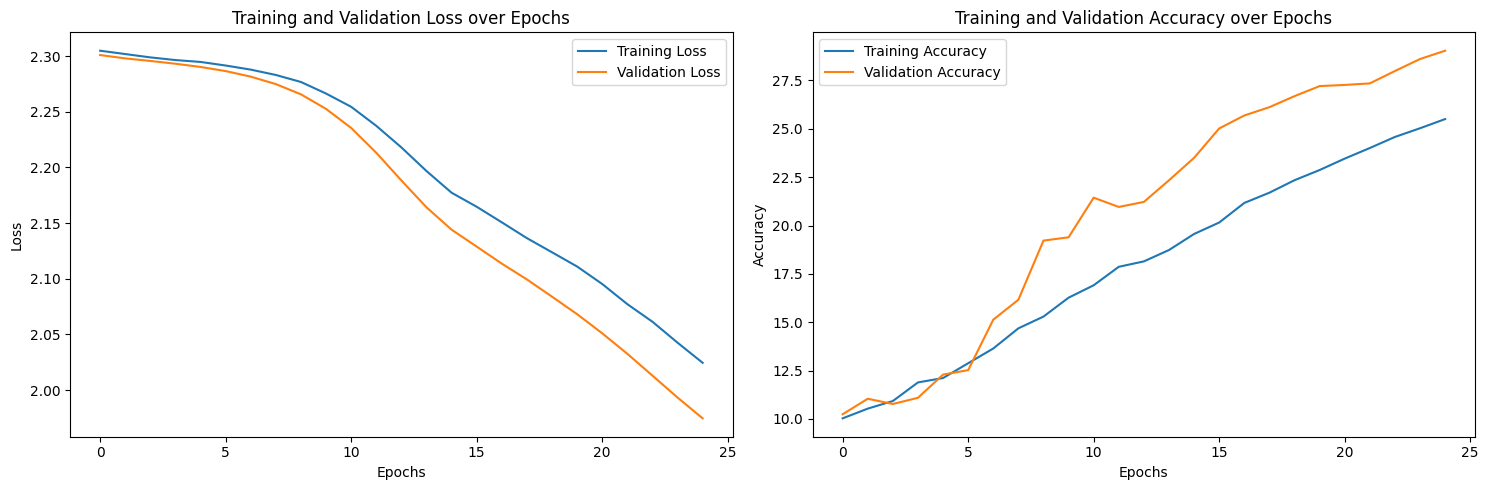

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot_cayAdam, label='Training Loss')
axs[0].plot(total_loss_validation_plot_cayAdam, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot_cayAdam, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot_cayAdam, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

plt.show()